In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

print("✅ CELL 1: All libraries imported!")

✅ CELL 1: All libraries imported!


In [ ]:
import pandas as pd
import os
import glob
from google.colab import files

print("📂 Please upload your file (either the .csv or the .zip):")
# This will create a "Choose Files" button directly under the cell
uploaded = files.upload()

# Get the exact name of the file you just uploaded
filename = list(uploaded.keys())[0]

# If you uploaded the zip, this unzips it for you
if filename.endswith('.zip'):
    os.system(f'unzip -o "{filename}"')
    csv_files = glob.glob("*.csv")
    target_csv = csv_files[0]
else:
    target_csv = filename

# Load the data
df = pd.read_csv(target_csv)
print(f"\n✅ CELL 2 SUCCESS! Loaded: {target_csv}")
print("Shape:", df.shape)
print(df.head(3))

📂 Please upload your file (either the .csv or the .zip):


Saving Metro_Interstate_Traffic_Volume.csv to Metro_Interstate_Traffic_Volume.csv

✅ CELL 2 SUCCESS! Loaded: Metro_Interstate_Traffic_Volume.csv
Shape: (48204, 9)
   traffic_volume holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0            5545     NaN  288.28      0.0      0.0          40       Clouds   
1            4516     NaN  289.36      0.0      0.0          75       Clouds   
2            4767     NaN  289.58      0.0      0.0          90       Clouds   

  weather_description         date_time  
0    scattered clouds  02-10-2012 09:00  
1       broken clouds  02-10-2012 10:00  
2     overcast clouds  02-10-2012 11:00  


In [ ]:
# 1. Date formatting (Bulletproof)
if 'date_time' in df.columns:
    df['date_time']   = pd.to_datetime(df['date_time'], dayfirst=True, format='mixed', errors='coerce')
    df['hour']        = df['date_time'].dt.hour
    df['day_of_week'] = df['date_time'].dt.dayofweek
    df['month']       = df['date_time'].dt.month
    df['year']        = df['date_time'].dt.year

# 2. Remove sensor errors
if 'temp' in df.columns:
    df = df[(df['temp'] > 200) & (df['temp'] < 320)]

# 3. Feature Engineering
if 'holiday' in df.columns:
    df['is_holiday']   = df['holiday'].apply(lambda x: 0 if x == 'None' else 1)
if 'hour' in df.columns:
    df['is_peak_hour'] = df['hour'].apply(lambda h: 1 if (7<=h<=9) or (16<=h<=19) else 0)
if 'day_of_week' in df.columns:
    df['is_weekend']   = df['day_of_week'].apply(lambda d: 1 if d >= 5 else 0)

# 4. Convert weather text (Checks if it exists first!)
if 'weather_main' in df.columns:
    df = pd.get_dummies(df, columns=['weather_main'], prefix='weather')

# 5. Create Traffic Congestion Levels
if 'traffic_volume' in df.columns:
    bins   = [0, 2000, 4000, df['traffic_volume'].max() + 1]
    labels = [0, 1, 2]
    df['congestion_level'] = pd.cut(df['traffic_volume'], bins=bins, labels=labels, include_lowest=True).astype(int)

# 6. Drop old columns safely
drop_cols = ['date_time', 'holiday', 'traffic_volume', 'weather_description']
existing_drop_cols = [c for c in drop_cols if c in df.columns]
df.drop(columns=existing_drop_cols, inplace=True)

print("✅ CELL 3: Preprocessing done. Final shape:", df.shape)

✅ CELL 3: Preprocessing done. Final shape: (48194, 23)


In [ ]:
# Separate the features (X) from the target we want to predict (y)
X = df.drop(columns=['congestion_level'])
y = df['congestion_level']

# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Identify the numerical columns that need to be scaled
num_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all']
scaler = StandardScaler()

# Train the scaler on the training data and transform both sets
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print(f"✅ CELL 4 SUCCESS: Scaling done!")
print(f"🧠 Training Data: {X_train.shape[0]} rows ready to teach the AI.")
print(f"🎯 Testing Data: {X_test.shape[0]} rows hidden for the final test.")

✅ CELL 4 SUCCESS: Scaling done!
🧠 Training Data: 38555 rows ready to teach the AI.
🎯 Testing Data: 9639 rows hidden for the final test.


In [ ]:
print("Training models... (this takes about 10-30 seconds)")

# 1. Train Random Forest (The Star Player)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15,
                                  min_samples_split=5, random_state=42,
                                  class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train, y_train)
print("✅ Random Forest trained successfully!")

# 2. Train Decision Tree (Baseline 1)
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)
print("✅ Decision Tree trained successfully!")

# 3. Train Logistic Regression (Baseline 2)
lr_model = LogisticRegression(max_iter=500, random_state=42)
lr_model.fit(X_train, y_train)
print("✅ Logistic Regression trained successfully!")

Training models... (this takes about 10-30 seconds)
✅ Random Forest trained successfully!
✅ Decision Tree trained successfully!
✅ Logistic Regression trained successfully!


In [ ]:
# Have the models take a "test" on the hidden data
y_pred_rf = rf_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)

class_names = ['Low', 'Medium', 'High']

# A small function to calculate and print the grades
def evaluate(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  Precision: {prec*100:.2f}%")
    print(f"  Recall   : {rec*100:.2f}%")
    print(f"  F1-Score : {f1*100:.2f}%")
    return acc, prec, rec, f1

# Get the report card for all three models
rf_s = evaluate("Random Forest", y_test, y_pred_rf)
dt_s = evaluate("Decision Tree", y_test, y_pred_dt)
lr_s = evaluate("Logistic Regression", y_test, y_pred_lr)

# Print the detailed breakdown for the best model (Random Forest)
print(f"\n{'='*50}\n  Detailed Report (Random Forest)\n{'='*50}")
print(classification_report(y_test, y_pred_rf, target_names=class_names))

print("\n✅ CELL 6: Evaluation complete!")


  Random Forest
  Accuracy : 92.41%
  Precision: 92.46%
  Recall   : 92.41%
  F1-Score : 92.41%

  Decision Tree
  Accuracy : 92.09%
  Precision: 92.07%
  Recall   : 92.09%
  F1-Score : 91.96%

  Logistic Regression
  Accuracy : 68.37%
  Precision: 67.54%
  Recall   : 68.37%
  F1-Score : 67.72%

  Detailed Report (Random Forest)
              precision    recall  f1-score   support

         Low       0.97      0.93      0.95      3043
      Medium       0.85      0.85      0.85      2409
        High       0.93      0.96      0.95      4187

    accuracy                           0.92      9639
   macro avg       0.92      0.91      0.92      9639
weighted avg       0.92      0.92      0.92      9639


✅ CELL 6: Evaluation complete!


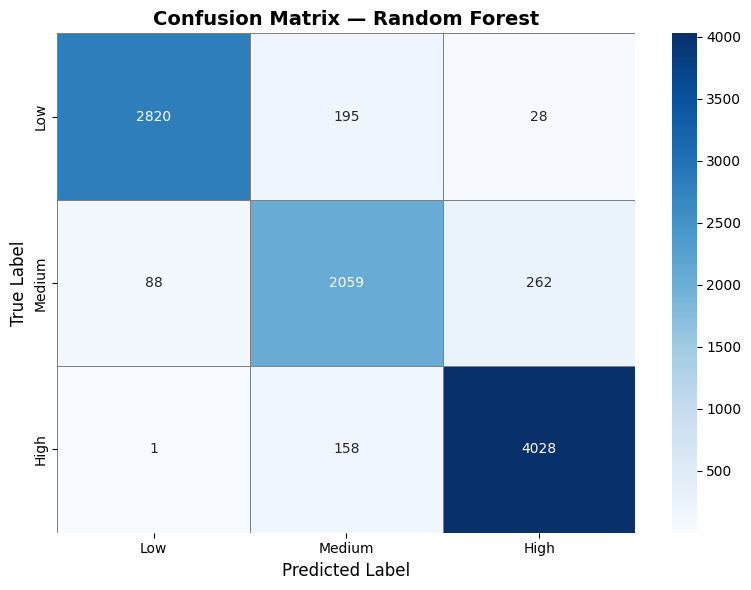

✅ CELL 7: Graph generated and saved as 'confusion_matrix.png'


In [ ]:
# Generate the Confusion Matrix for the best model
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='gray')

plt.title('Confusion Matrix — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()

# Save the image automatically so you can put it in your Word document
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("✅ CELL 7: Graph generated and saved as 'confusion_matrix.png'")

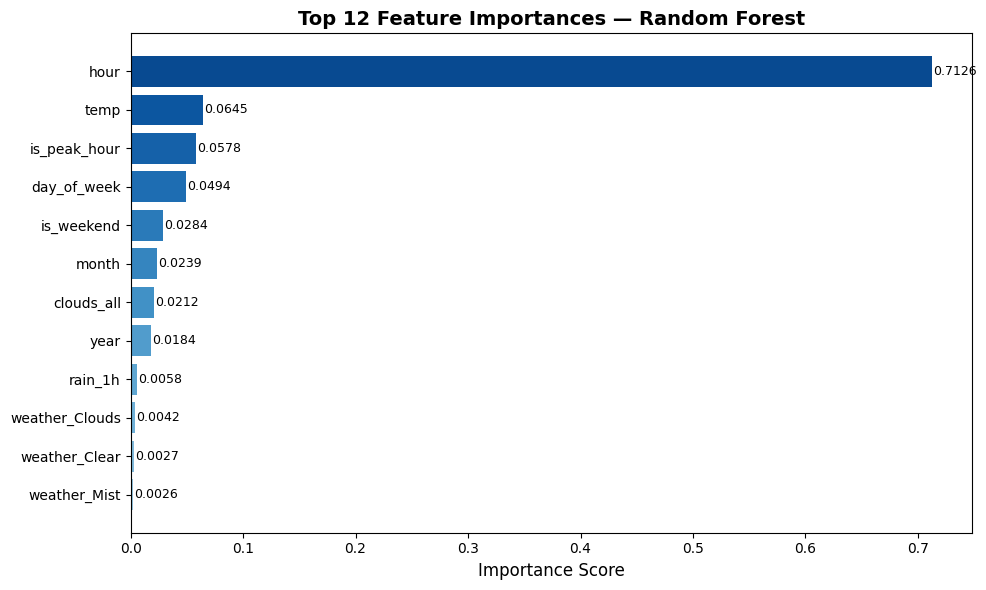

✅ CELL 8: Graph generated and saved as 'feature_importance.png'


In [ ]:
# Extract the "importance" scores from our trained Random Forest
feat_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

plt.figure(figsize=(10, 6))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(feat_df)))[::-1]
bars = plt.barh(feat_df['Feature'], feat_df['Importance'], color=colors)

# Add the exact numbers next to the bars
for bar, val in zip(bars, feat_df['Importance']):
    plt.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.title('Top 12 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()

# Save the image automatically
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("✅ CELL 8: Graph generated and saved as 'feature_importance.png'")

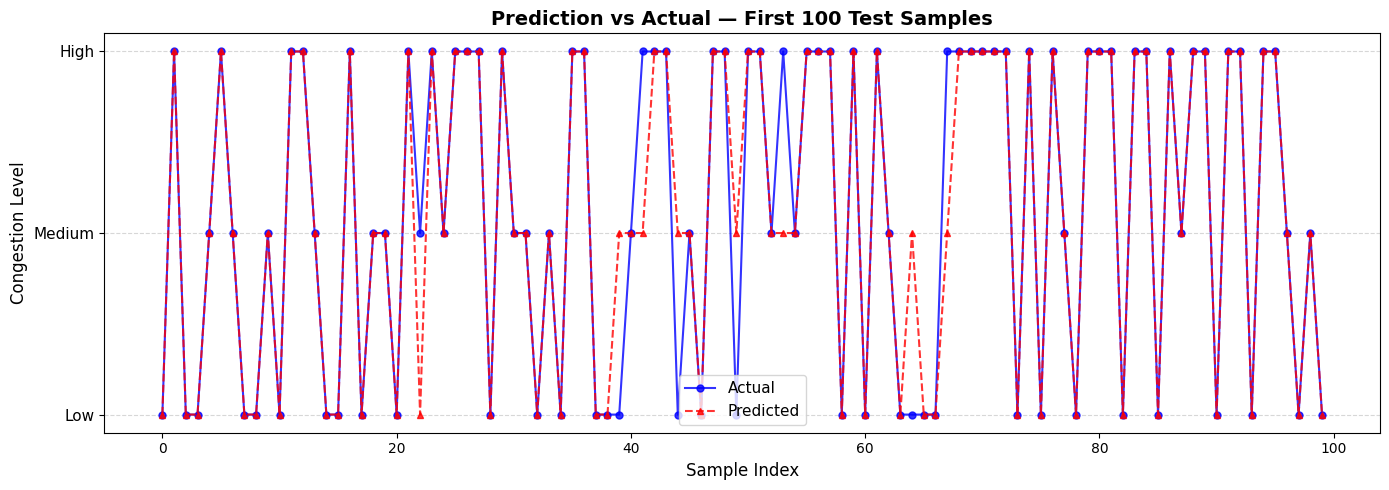

✅ CELL 9: Graph generated and saved as 'pred_vs_actual.png'


In [ ]:
N = 100
plt.figure(figsize=(14, 5))

# Plot the real data (Blue circles)
plt.plot(range(N), y_test.values[:N], 'bo-', label='Actual',
         markersize=5, linewidth=1.5, alpha=0.8)

# Plot the AI's predictions (Red triangles)
plt.plot(range(N), y_pred_rf[:N], 'r^--', label='Predicted',
         markersize=5, linewidth=1.5, alpha=0.8)

plt.yticks([0, 1, 2], ['Low', 'Medium', 'High'], fontsize=11)
plt.title(f'Prediction vs Actual — First {N} Test Samples', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Congestion Level', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save the image automatically
plt.savefig('pred_vs_actual.png', dpi=150)
plt.show()

print("✅ CELL 9: Graph generated and saved as 'pred_vs_actual.png'")

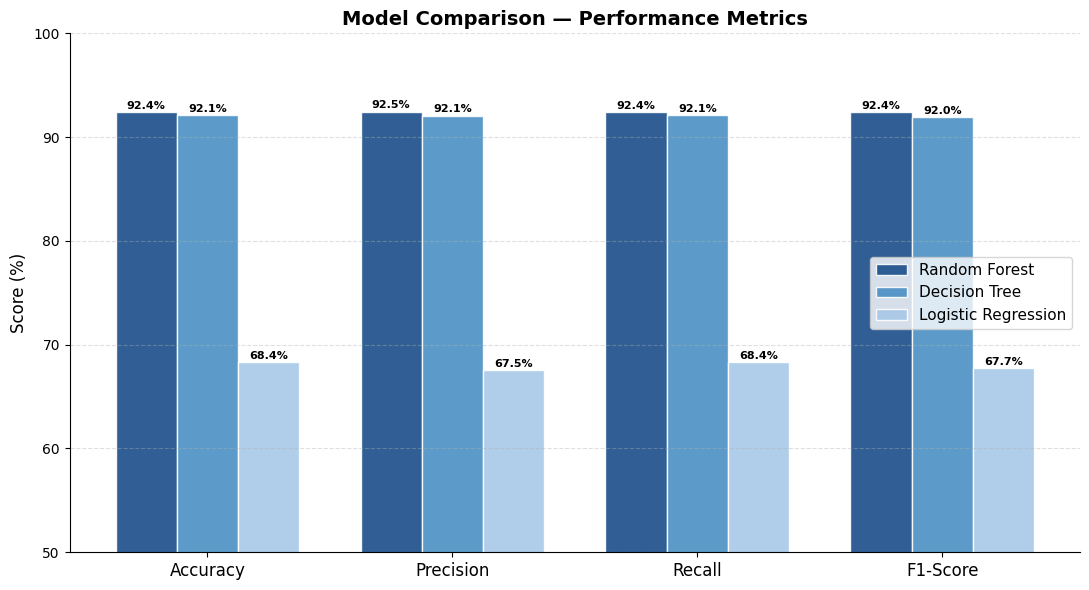

✅ CELL 10: Graph generated and saved as 'model_comparison.png'


In [ ]:
models  = ['Random\nForest', 'Decision\nTree', 'Logistic\nRegression']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors  = ['#1a4e8a', '#4a90c4', '#a8c8e8']
x = np.arange(len(metrics))
w = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

# Draw the bars for all three models side-by-side
for i, (name, scores) in enumerate(zip(models, [rf_s, dt_s, lr_s])):
    bars = ax.bar(x + i*w, [s*100 for s in scores], w,
                  label=name.replace('\n',' '), color=colors[i], alpha=0.9, edgecolor='white')

    # Put the exact percentage number on top of each bar
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')

ax.set_title('Model Comparison — Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + w)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(50, 100)  # Adjusted so the bars fit nicely
ax.set_ylabel('Score (%)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Clean up the borders to make it look professional
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

# Save the image automatically
plt.savefig('model_comparison.png', dpi=150)
plt.show()

print("✅ CELL 10: Graph generated and saved as 'model_comparison.png'")

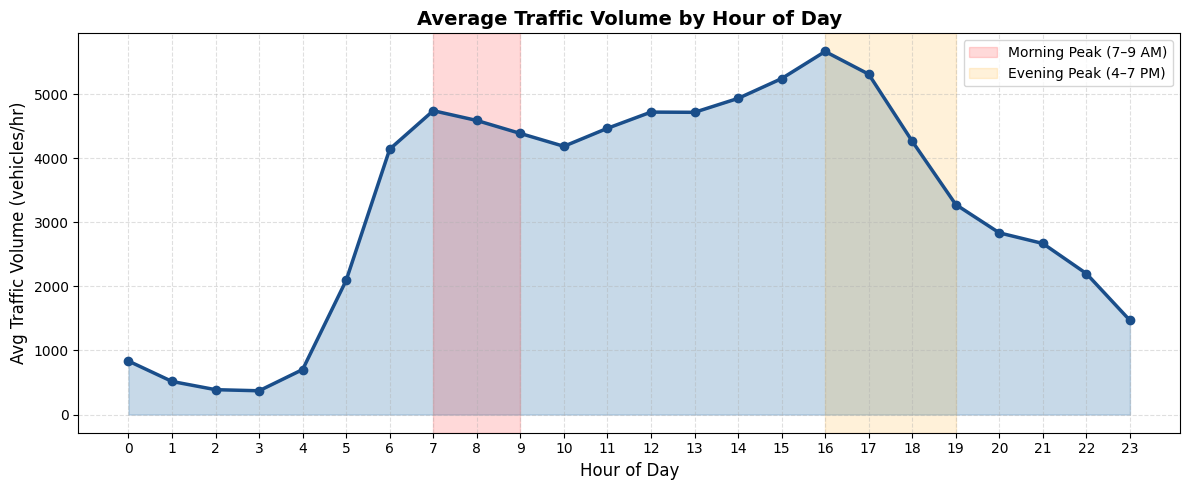

✅ CELL 11: Graph generated and saved as 'hourly_traffic_pattern.png'


In [ ]:
import glob

# Reload the original raw data just for this one graph
csv_files = glob.glob("*.csv")
df_orig = pd.read_csv(csv_files[0])

# Extract the hour
df_orig['date_time'] = pd.to_datetime(df_orig['date_time'], dayfirst=True, format='mixed', errors='coerce')
df_orig['hour'] = df_orig['date_time'].dt.hour

# Calculate average traffic per hour
hourly_avg = df_orig.groupby('hour')['traffic_volume'].mean()

plt.figure(figsize=(12, 5))
plt.fill_between(hourly_avg.index, hourly_avg.values, alpha=0.3, color='steelblue')
plt.plot(hourly_avg.index, hourly_avg.values, 'o-', color='#1a4e8a', linewidth=2.5, markersize=6)

# Highlight the rush hours
plt.axvspan(7, 9,   alpha=0.15, color='red',    label='Morning Peak (7–9 AM)')
plt.axvspan(16, 19, alpha=0.15, color='orange', label='Evening Peak (4–7 PM)')

plt.title('Average Traffic Volume by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Avg Traffic Volume (vehicles/hr)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(linestyle='--', alpha=0.4)
plt.legend(fontsize=10)
plt.tight_layout()

# Save the image automatically
plt.savefig('hourly_traffic_pattern.png', dpi=150)
plt.show()

print("✅ CELL 11: Graph generated and saved as 'hourly_traffic_pattern.png'")

In [ ]:
from google.colab import files
import time

print("Preparing your files for download...")

graphs_to_download = [
    'confusion_matrix.png',
    'feature_importance.png',
    'pred_vs_actual.png',
    'model_comparison.png',
    'hourly_traffic_pattern.png'
]

for f in graphs_to_download:
    try:
        files.download(f)
        print(f"⬇️ Downloading: {f}")
        # A tiny pause so Google Chrome doesn't block multiple downloads
        time.sleep(1.5)
    except Exception as e:
        print(f"⚠️ Could not download {f}. You might need to right-click and save it manually.")

print("\n🎉 EXPERIMENT COMPLETE! Congratulations on finishing your AI Smart City project!")

Preparing your files for download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Downloading: confusion_matrix.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

⬇️ Downloading: model_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Downloading: hourly_traffic_pattern.png

🎉 EXPERIMENT COMPLETE! Congratulations on finishing your AI Smart City project!
